In [1]:
%%writefile thesis_loader.py
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import torch
from pathlib import Path
from typing import Dict, Tuple

class EllipticPlusPlusThesisLoader:
    def __init__(self, data_dir="/kaggle/input/datasets/etsitoni/elliptic-plus", random_state=42):
        self.data_dir = Path(data_dir)
        self.random_state = random_state
        self.tx_features = None
        self.tx_labels = None
        self.tx_timesteps = None
        self.wallet_features = None
        self.edges = None
        self.train_mask = None
        self.test_mask = None
        self.tx_scaler = MinMaxScaler()
        self.wallet_scaler = MinMaxScaler()

    def load_data(self):
        print("Loading Features (Tx)...")
        txs_features = pd.read_csv(self.data_dir / "elliptic_txs_features.csv", header=None)
        tx_ids = txs_features.iloc[:, 0].values
        timesteps = txs_features.iloc[:, 1].values
        features = txs_features.iloc[:, 2:].values.astype(np.float32)
        
        del txs_features
        import gc; gc.collect()

        print("Loading Labels...")
        txs_classes = pd.read_csv(self.data_dir / "elliptic_txs_classes.csv")
        df = pd.DataFrame({'txId': tx_ids, 'timestep': timesteps})
        df = df.merge(txs_classes, on='txId', how='left')
        labels = df['class'].values
        
        labeled_mask = (labels == '1') | (labels == '2')
        features = features[labeled_mask]
        timesteps = timesteps[labeled_mask]
        labels = labels[labeled_mask]
        tx_ids = tx_ids[labeled_mask]
        
        binary_labels = np.zeros(len(labels), dtype=np.int64)
        binary_labels[labels == '1'] = 1
        binary_labels[labels == '2'] = 0
        
        self.tx_features = features
        self.tx_labels = binary_labels
        self.tx_timesteps = timesteps

        print("Loading Wallets...")
        try:
            wallets_features = pd.read_csv(
                self.data_dir / "wallets_features.csv",
                header=0,
                dtype={0: str}
            )
            self.wallet_features = wallets_features.iloc[:, 1:].values.astype(np.float32)
            del wallets_features
            gc.collect()
        except FileNotFoundError:
            self.wallet_features = None

        print("Loading Edges...")
        txs_edgelist = pd.read_csv(self.data_dir / "elliptic_txs_edgelist.csv", header=0)
        
        id_map = {raw_id: idx for idx, raw_id in enumerate(tx_ids)}
        txs_edgelist['txId1'] = txs_edgelist['txId1'].map(id_map)
        txs_edgelist['txId2'] = txs_edgelist['txId2'].map(id_map)
        txs_edgelist = txs_edgelist.dropna().astype(int)
        
        self.edges = txs_edgelist.values
        
        self._create_temporal_split()
        return self

    def _create_temporal_split(self):
        self.train_mask = self.tx_timesteps <= 34
        self.test_mask = self.tx_timesteps > 34
        self.tx_scaler.fit(self.tx_features[self.train_mask])
        self.tx_features = self.tx_scaler.transform(self.tx_features)
        if self.wallet_features is not None:
            self.wallet_features = self.wallet_scaler.fit_transform(self.wallet_features)

    def get_rf_data(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        X_train = self.tx_features[self.train_mask]
        y_train = self.tx_labels[self.train_mask]
        X_test = self.tx_features[self.test_mask]
        y_test = self.tx_labels[self.test_mask]
        return X_train, y_train, X_test, y_test

    def get_graph_data(self, include_wallets=True) -> Dict:
        data = {
            'x_tx': torch.FloatTensor(self.tx_features),
            'y': torch.LongTensor(self.tx_labels),
            'edge_index': torch.LongTensor(self.edges.T),
            'train_mask': torch.BoolTensor(self.train_mask),
            'test_mask': torch.BoolTensor(self.test_mask),
            'timesteps': self.tx_timesteps,
            'n_tx_features': self.tx_features.shape[1]
        }
        if include_wallets and self.wallet_features is not None:
            data['x_wallet'] = torch.FloatTensor(self.wallet_features)
        return data

if __name__ == "__main__":
    loader = EllipticPlusPlusThesisLoader(data_dir="/kaggle/input/elliptic-plus")
    loader.load_data()

Writing thesis_loader.py


In [2]:
%%writefile thesis_supervised_baselines.py
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time
from datetime import datetime
from thesis_loader import EllipticPlusPlusThesisLoader

class SupervisedBaselines:
    def __init__(self, random_state=42):
        self.random_state = random_state

    def _evaluate(self, y_true, y_pred, y_proba, model_name="Model"):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        metrics = {
            f'{model_name}_precision': precision_score(y_true, y_pred, zero_division=0),
            f'{model_name}_recall': recall_score(y_true, y_pred, zero_division=0),
            f'{model_name}_f1': f1_score(y_true, y_pred, zero_division=0),
            f'{model_name}_auc': roc_auc_score(y_true, y_proba),
            f'{model_name}_tp': int(tp),
            f'{model_name}_tn': int(tn),
            f'{model_name}_fp': int(fp),
            f'{model_name}_fn': int(fn),
        }
        print(f"\n{model_name} Results:")
        print(classification_report(y_true, y_pred, target_names=['Licit', 'Illicit']))
        return metrics

    def run_lr_baseline(self, X_train, y_train, X_test, y_test):
        lr = LogisticRegression(
            solver='saga',
            class_weight='balanced',
            max_iter=2000,
            random_state=self.random_state
        )
        start = time.time()
        lr.fit(X_train, y_train)
        train_time = time.time() - start

        y_pred = lr.predict(X_test)
        y_proba = lr.predict_proba(X_test)[:, 1]
        metrics = self._evaluate(y_test, y_pred, y_proba, "Logistic Regression")
        metrics['train_time'] = train_time
        metrics['n_samples'] = len(y_train)
        return metrics

    def run_rf_baseline(self, X_train, y_train, X_test, y_test, refine_features=True):
        rf = RandomForestClassifier(
            n_estimators=50,
            class_weight='balanced',
            random_state=self.random_state,
            n_jobs=-1
        )
        start = time.time()
        rf.fit(X_train, y_train)
        train_time = time.time() - start

        if refine_features:
            importances = rf.feature_importances_
            top_k = 100
            top_indices = np.argsort(importances)[-top_k:]
            X_train_ref = X_train[:, top_indices]
            X_test_ref  = X_test[:, top_indices]

            rf_ref = RandomForestClassifier(
                n_estimators=50,
                class_weight='balanced',
                random_state=self.random_state,
                n_jobs=-1
            )
            rf_ref.fit(X_train_ref, y_train)
            y_pred = rf_ref.predict(X_test_ref)
            y_proba = rf_ref.predict_proba(X_test_ref)[:, 1]
            model_name = "RF with Feature Refinement"
        else:
            y_pred = rf.predict(X_test)
            y_proba = rf.predict_proba(X_test)[:, 1]
            model_name = "Random Forest"

        metrics = self._evaluate(y_test, y_pred, y_proba, model_name)
        metrics['train_time'] = train_time
        metrics['n_samples'] = len(y_train)
        return metrics

def run_supervised_experiments():
    loader = EllipticPlusPlusThesisLoader(data_dir="/kaggle/input/elliptic-plus")
    loader.load_data()
    
    X_train, y_train, X_test, y_test = loader.get_rf_data()
    
    baselines = SupervisedBaselines(random_state=42)
    
    lr_results = baselines.run_lr_baseline(X_train, y_train, X_test, y_test)
    rf_results = baselines.run_rf_baseline(X_train, y_train, X_test, y_test, refine_features=True)
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    pd.DataFrame([lr_results, rf_results]).to_csv(
        f"/kaggle/working/thesis_supervised_baselines_{timestamp}.csv", index=False
    )
    print(f"Saved to thesis_supervised_baselines_{timestamp}.csv")
    
    return lr_results, rf_results

if __name__ == "__main__":
    run_supervised_experiments()

Writing thesis_supervised_baselines.py


In [3]:
from thesis_supervised_baselines import run_supervised_experiments, SupervisedBaselines
from thesis_loader import EllipticPlusPlusThesisLoader


loader = EllipticPlusPlusThesisLoader(data_dir="/kaggle/input/datasets/etsitoni/elliptic-plus")
loader.load_data()
X_train, y_train, X_test, y_test = loader.get_rf_data()

baselines = SupervisedBaselines(random_state=42)

lr_results = baselines.run_lr_baseline(X_train, y_train, X_test, y_test)

rf_base_results = baselines.run_rf_baseline(X_train, y_train, X_test, y_test, refine_features=False)

rf_refined_results = baselines.run_rf_baseline(X_train, y_train, X_test, y_test, refine_features=True)

Loading Features (Tx)...
Loading Labels...
Loading Wallets...
Loading Edges...

Logistic Regression Results:
              precision    recall  f1-score   support

       Licit       0.99      0.61      0.76     15587
     Illicit       0.14      0.94      0.25      1083

    accuracy                           0.63     16670
   macro avg       0.57      0.78      0.50     16670
weighted avg       0.94      0.63      0.73     16670


Random Forest Results:
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.99      0.69      0.81      1083

    accuracy                           0.98     16670
   macro avg       0.98      0.84      0.90     16670
weighted avg       0.98      0.98      0.98     16670


RF with Feature Refinement Results:
              precision    recall  f1-score   support

       Licit       0.98      1.00      0.99     15587
     Illicit       0.98      0.67      0.80      1083

    accuracy

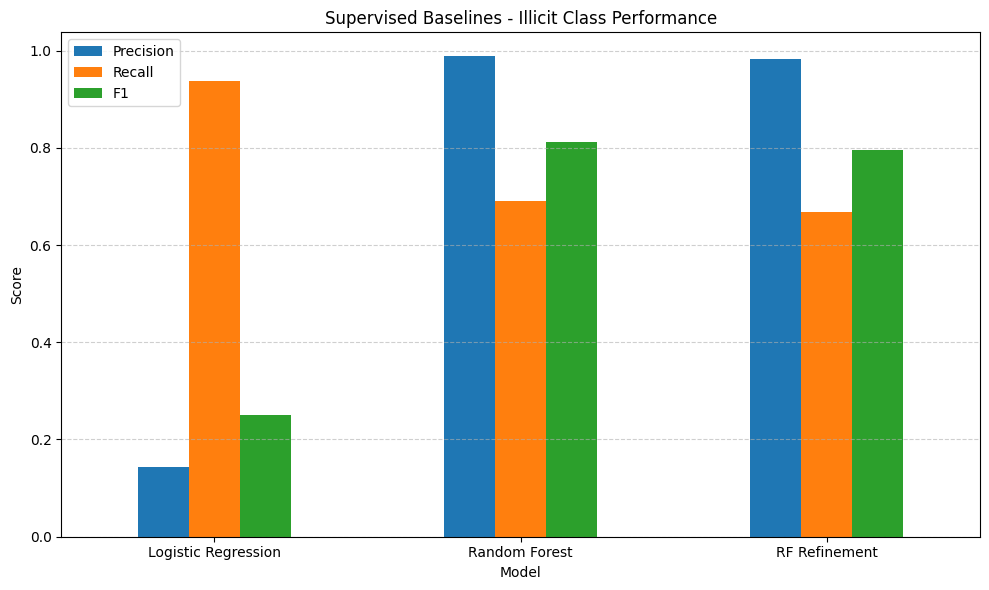

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'Model': ['Logistic Regression', 'Random Forest', 'RF Refinement'],
    'Precision': [
        lr_results['Logistic Regression_precision'], 
        rf_base_results['Random Forest_precision'], 
        rf_refined_results['RF with Feature Refinement_precision']
    ],
    'Recall': [
        lr_results['Logistic Regression_recall'], 
        rf_base_results['Random Forest_recall'], 
        rf_refined_results['RF with Feature Refinement_recall']
    ],
    'F1': [
        lr_results['Logistic Regression_f1'], 
        rf_base_results['Random Forest_f1'], 
        rf_refined_results['RF with Feature Refinement_f1']
    ]
}

df_plot = pd.DataFrame(data).set_index('Model')
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title('Supervised Baselines - Illicit Class Performance')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('/kaggle/working/supervised_comparison.png', dpi=300)
plt.show()

In [5]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.3 MB/s eta 0:00:00a 0:00:01


In [6]:
%%writefile thesis_gnn_models.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HGTConv, HANConv
from torch_geometric.data import HeteroData
import numpy as np
import pandas as pd
import time
from datetime import datetime
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix
from thesis_loader import EllipticPlusPlusThesisLoader

class HAN(nn.Module):
    def __init__(self, in_channels_dict, hidden_channels=128, out_channels=2, num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.dropout = dropout
        self.proj_dict = nn.ModuleDict()
        for node_type, in_channels in in_channels_dict.items():
            self.proj_dict[node_type] = nn.Linear(in_channels, hidden_channels)

        metadata = (['transaction', 'wallet'], [
            ('transaction', 'to', 'transaction'),
            ('wallet', 'to', 'transaction'),
            ('transaction', 'to', 'wallet')
        ])
        
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv = HANConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                heads=num_heads,
                dropout=dropout,
                metadata=metadata
            )
            self.convs.append(conv)
        self.output = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {node_type: self.proj_dict[node_type](x).relu() for node_type, x in x_dict.items()}
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            new_x_dict = {}
            for k, v in x_dict.items():
                if v is not None:
                    new_x_dict[k] = F.dropout(v, p=self.dropout, training=self.training)
            x_dict = new_x_dict
        return self.output(x_dict['transaction'])

class HGT(nn.Module):
    def __init__(self, in_channels_dict, hidden_channels=128, out_channels=2, num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        metadata = (['transaction', 'wallet'], [
            ('transaction', 'to', 'transaction'),
            ('wallet', 'to', 'transaction'),
            ('transaction', 'to', 'wallet')
        ])
        
        self.lin_dict = nn.ModuleDict()
        for node_type, in_channels in in_channels_dict.items():
            self.lin_dict[node_type] = nn.Linear(in_channels, hidden_channels)
            
        self.convs = nn.ModuleList()
        for _ in range(num_layers):
            conv = HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads)
            self.convs.append(conv)
        self.out = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {node_type: self.lin_dict[node_type](x).relu() for node_type, x in x_dict.items()}
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
        return self.out(x_dict['transaction'])

class GNNTrainer:
    def __init__(self, model, device='cuda' if torch.cuda.is_available() else 'cpu', lr=0.001, weight_decay=5e-4):
        self.model = model.to(device)
        self.device = device
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        self.class_weights = None

    def set_class_weights(self, y_train):
        n_samples = len(y_train)
        n_illicit = torch.sum(y_train == 1).item()
        n_licit = n_samples - n_illicit
        weight_illicit = n_samples / (2 * n_illicit) if n_illicit > 0 else 1.0
        weight_licit = n_samples / (2 * n_licit) if n_licit > 0 else 1.0
        self.class_weights = torch.FloatTensor([weight_licit, weight_illicit]).to(self.device)

    def train_epoch(self, data, train_mask):
        self.model.train()
        self.optimizer.zero_grad()
        out = self.model(data.x_dict, data.edge_index_dict)
        y_target = data['transaction'].y[train_mask]
        loss = F.cross_entropy(out[train_mask], y_target, weight=self.class_weights)
        loss.backward()
        self.optimizer.step()
        return loss.item()

    @torch.no_grad()
    def evaluate(self, data, mask, set_name="Test"):
        self.model.eval()
        out = self.model(data.x_dict, data.edge_index_dict)
        y_true = data['transaction'].y[mask].cpu().numpy()
        y_pred = out[mask].argmax(dim=1).cpu().numpy()
        y_proba = F.softmax(out[mask], dim=1)[:, 1].cpu().numpy()
        
        metrics = {
            f'{set_name}_precision': precision_score(y_true, y_pred, zero_division=0),
            f'{set_name}_recall': recall_score(y_true, y_pred, zero_division=0),
            f'{set_name}_f1': f1_score(y_true, y_pred, zero_division=0),
            f'{set_name}_auc': roc_auc_score(y_true, y_proba),
        }
        return metrics

    def train(self, data, train_mask, test_mask, epochs=200, patience=20):
        y_train = data['transaction'].y[train_mask]
        self.set_class_weights(y_train)
        best_test_recall = 0
        patience_counter = 0
        history = []
        
        for epoch in range(epochs):
            loss = self.train_epoch(data, train_mask)
            test_metrics = self.evaluate(data, test_mask, "test")
            history.append({'epoch': epoch, 'train_loss': loss, **test_metrics})
            
            if test_metrics['test_recall'] > best_test_recall:
                best_test_recall = test_metrics['test_recall']
                patience_counter = 0
                self.best_state = self.model.state_dict()
            else:
                patience_counter += 1
            
            if epoch % 10 == 0:
                print(f"Epoch {epoch}: Loss={loss:.4f} | Recall={test_metrics['test_recall']:.4f}")
            if patience_counter >= patience:
                break
        
        if hasattr(self, 'best_state'):
            self.model.load_state_dict(self.best_state)
        return history

def run_han_experiment(loader):
    print("\nRunning HAN (Heterogeneous: Tx + Wallets)...")
    graph_dict = loader.get_graph_data(include_wallets=True)
    data = HeteroData()
    data['transaction'].x = graph_dict['x_tx']
    data['transaction'].y = graph_dict['y']
    in_channels_dict = {'transaction': graph_dict['n_tx_features']}
    if 'x_wallet' in graph_dict:
        data['wallet'].x = graph_dict['x_wallet']
        in_channels_dict['wallet'] = graph_dict['x_wallet'].shape[1]
    data['transaction', 'to', 'transaction'].edge_index = graph_dict['edge_index']
    model = HAN(in_channels_dict=in_channels_dict)
    trainer = GNNTrainer(model)
    data = data.to(trainer.device)
    history = trainer.train(data, graph_dict['train_mask'], graph_dict['test_mask'])
    final_metrics = trainer.evaluate(data, graph_dict['test_mask'], "test")
    return pd.DataFrame(history), final_metrics

def run_hgt_experiment(loader):
    print("\nRunning HGT (Heterogeneous: Tx + Wallets)...")
    graph_dict = loader.get_graph_data(include_wallets=True)
    data = HeteroData()
    data['transaction'].x = graph_dict['x_tx']
    data['transaction'].y = graph_dict['y']
    in_channels_dict = {'transaction': graph_dict['n_tx_features']}
    if 'x_wallet' in graph_dict:
        data['wallet'].x = graph_dict['x_wallet']
        in_channels_dict['wallet'] = graph_dict['x_wallet'].shape[1]
    data['transaction', 'to', 'transaction'].edge_index = graph_dict['edge_index']
    model = HGT(in_channels_dict=in_channels_dict)
    trainer = GNNTrainer(model)
    data = data.to(trainer.device)
    history = trainer.train(data, graph_dict['train_mask'], graph_dict['test_mask'])
    final_metrics = trainer.evaluate(data, graph_dict['test_mask'], "test")
    return pd.DataFrame(history), final_metrics

def run_all_gnn_experiments():
    loader = EllipticPlusPlusThesisLoader()
    loader.load_data()
    df_han, metrics_han = run_han_experiment(loader)
    df_hgt, metrics_hgt = run_hgt_experiment(loader)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    df_han.to_csv(f"thesis_han_history_{timestamp}.csv", index=False)
    df_hgt.to_csv(f"thesis_hgt_history_{timestamp}.csv", index=False)
    print("\nHeterogeneous GNN Experiments Completed.")
    return {'HAN': metrics_han, 'HGT': metrics_hgt}

if __name__ == "__main__":
    run_all_gnn_experiments()

Writing thesis_gnn_models.py


In [7]:
from thesis_gnn_models import run_all_gnn_experiments

results = run_all_gnn_experiments()

Loading Features (Tx)...
Loading Labels...
Loading Wallets...
Loading Edges...

Running HAN (Heterogeneous: Tx + Wallets)...
Epoch 0: Loss=0.6952 | Recall=0.9963
Epoch 10: Loss=0.6799 | Recall=0.7710
Epoch 20: Loss=0.6472 | Recall=0.7867

Running HGT (Heterogeneous: Tx + Wallets)...
Epoch 0: Loss=0.6929 | Recall=0.2419
Epoch 10: Loss=0.6705 | Recall=0.7710
Epoch 20: Loss=0.6437 | Recall=0.7710
Epoch 30: Loss=0.5687 | Recall=0.9049
Epoch 40: Loss=0.5462 | Recall=0.8966

Heterogeneous GNN Experiments Completed.


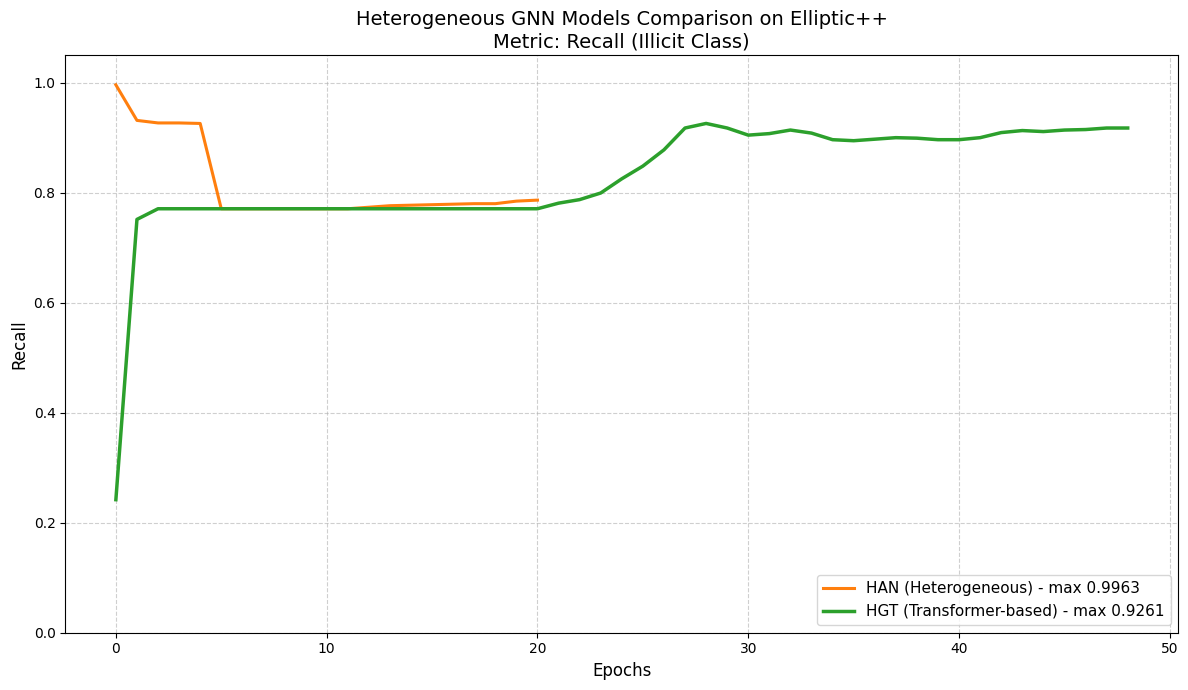

Plot saved to /kaggle/working/thesis_gnn_comparison.png


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

def plot_gnn_comparison():
    search_path = "/kaggle/working/"
    
    # Ψάχνουμε μόνο για HAN και HGT
    han_files = glob.glob(search_path + "thesis_han_history_*.csv")
    hgt_files = glob.glob(search_path + "thesis_hgt_history_*.csv")
    
    if not (han_files and hgt_files):
        print("Missing GNN history files. Run run_all_gnn_experiments() first.")
        return
    
    latest_han = max(han_files, key=os.path.getctime)
    latest_hgt = max(hgt_files, key=os.path.getctime)
    
    df_han = pd.read_csv(latest_han)
    df_hgt = pd.read_csv(latest_hgt)
    
    plt.figure(figsize=(12, 7))
    
    # Plotting HAN
    plt.plot(df_han['epoch'], df_han['test_recall'], 
             label=f'HAN (Heterogeneous) - max {df_han["test_recall"].max():.4f}', 
             linewidth=2.2, color='tab:orange')
    
    # Plotting HGT
    plt.plot(df_hgt['epoch'], df_hgt['test_recall'], 
             label=f'HGT (Transformer-based) - max {df_hgt["test_recall"].max():.4f}', 
             linewidth=2.5, color='tab:green')
    
    plt.title('Heterogeneous GNN Models Comparison on Elliptic++\nMetric: Recall (Illicit Class)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Recall', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    
    save_path = "/kaggle/working/thesis_gnn_comparison.png"
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Plot saved to {save_path}")

if __name__ == "__main__":
    plot_gnn_comparison()